In [34]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision
from pathlib import Path

from torch import nn
from torchvision import transforms
import going_modular.data_setup as data_setup 
import going_modular.engine as engine

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    %pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work

    import going_modular.data_setup as data_setup

    import going_modular.engine as engine 


In [35]:
# Setup device agnostic code
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")
device

Using device: mps


device(type='mps')

In [36]:
data_dir = Path("/Users/swapneelpremchand/PyTorch/PyTorchFol/data")
image_path = data_dir/"pizza_steak_sushi"

image_path

PosixPath('/Users/swapneelpremchand/PyTorch/PyTorchFol/data/pizza_steak_sushi')

In [37]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [38]:
# Create a transforms pipeline manually (required for torchvision < 0.13)
manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [39]:
# Get a set of pretrained model weights
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # .DEFAULT = best available weights from pretraining on ImageNet
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [40]:
# Get the transforms used to create our pretrained weights
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [41]:
# Create training and testing DataLoaders as well as get a list of class names
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=auto_transforms, # perform same data transforms on our own data as the pretrained model
                                                                               batch_size=32) # set mini-batch size to 32

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x16902c430>,
 ['pizza', 'steak', 'sushi'])

In [112]:
weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT

In [113]:
model = torchvision.models.efficientnet_b2(weights= weights)

In [114]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [115]:
summary(model=model , input_size= (32 , 3, 224 , 224))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [32, 1000]                --
├─Sequential: 1-1                                       [32, 1408, 7, 7]          --
│    └─Conv2dNormActivation: 2-1                        [32, 32, 112, 112]        --
│    │    └─Conv2d: 3-1                                 [32, 32, 112, 112]        864
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        64
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        --
│    └─Sequential: 2-2                                  [32, 16, 112, 112]        --
│    │    └─MBConv: 3-4                                 [32, 16, 112, 112]        1,448
│    │    └─MBConv: 3-5                                 [32, 16, 112, 112]        612
│    └─Sequential: 2-3                                  [32, 24, 56, 56]          --
│    │    └─MBConv: 3-6                                

In [116]:
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model.features.parameters():
    param.requires_grad = False

In [117]:
torch.manual_seed(seed=1000)
torch.mps.manual_seed(seed=1000)

output_shape = len(class_names)

# Replace classifier BEFORE moving to device
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1408, out_features=output_shape, bias=True)
)

# Move entire model to device (all parameters)
model = model.to(device)

print(f"Model device: {next(model.parameters()).device}")

Model device: mps:0


In [118]:
summary(model= model , input_size=(32 , 3 , 224 , 224))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [32, 3]                   --
├─Sequential: 1-1                                       [32, 1408, 7, 7]          --
│    └─Conv2dNormActivation: 2-1                        [32, 32, 112, 112]        --
│    │    └─Conv2d: 3-1                                 [32, 32, 112, 112]        (864)
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        (64)
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        --
│    └─Sequential: 2-2                                  [32, 16, 112, 112]        --
│    │    └─MBConv: 3-4                                 [32, 16, 112, 112]        (1,448)
│    │    └─MBConv: 3-5                                 [32, 16, 112, 112]        (612)
│    └─Sequential: 2-3                                  [32, 24, 56, 56]          --
│    │    └─MBConv: 3-6                        

In [119]:
# Define loss and optimizer (after model is on device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [125]:
from timeit import default_timer as timer 

start = timer()

results = engine.train(model=model, 
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader, 
                       optimizer=optimizer, 
                       loss_fn=loss_fn,
                       epochs=10, 
                       device=device)  # pass device object, not string

end = timer()

print(f"Time taken: {end - start:.2f} seconds")

 10%|█         | 1/10 [00:02<00:20,  2.29s/it]

Epoch: 1 | train_loss: 0.2934 | train_acc: 0.8398 | test_loss: 0.3316 | test_acc: 0.9479


 20%|██        | 2/10 [00:04<00:17,  2.18s/it]

Epoch: 2 | train_loss: 0.2950 | train_acc: 0.8438 | test_loss: 0.3410 | test_acc: 0.9176


 30%|███       | 3/10 [00:06<00:15,  2.15s/it]

...

Epoch: 8 | train_loss: 0.2641 | train_acc: 0.8594 | test_loss: 0.3765 | test_acc: 0.9072


 90%|█████████ | 9/10 [00:19<00:02,  2.12s/it]

Epoch: 9 | train_loss: 0.3406 | train_acc: 0.8359 | test_loss: 0.3519 | test_acc: 0.9176


100%|██████████| 10/10 [00:21<00:00,  2.13s/it]

Epoch: 10 | train_loss: 0.1843 | train_acc: 0.9727 | test_loss: 0.3176 | test_acc: 0.9384
Time taken: 21.31 seconds


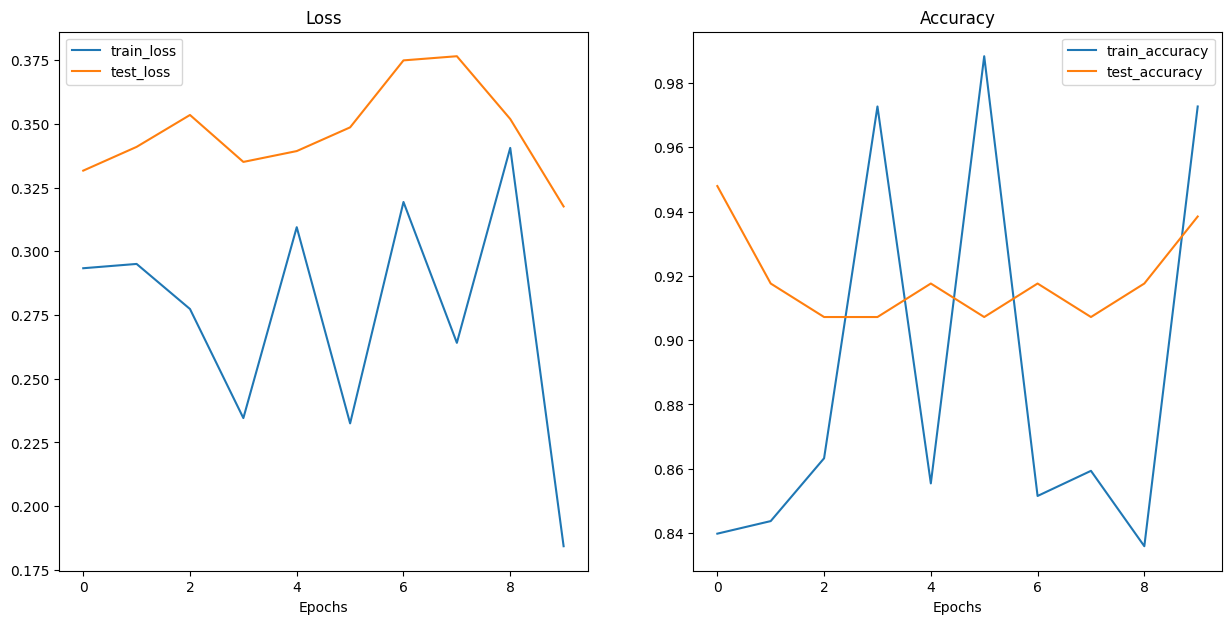

In [126]:
# Get the plot_loss_curves() function from helper_functions.py, download the file if we don't have it
try:
    from helper_functions import plot_loss_curves
except:
    print("[INFO] Couldn't find helper_functions.py, downloading...")
    with open("helper_functions.py", "wb") as f:
        import requests
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
        f.write(request.content)
    from helper_functions import plot_loss_curves

# Plot the loss curves of our model
plot_loss_curves(results)

In [127]:
from typing import List, Tuple

from PIL import Image

def pred_and_plot_image(model: torch.nn.Module, 
                        image_path: str, 
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform=None,
                        device: torch.device = device):
    
    img = Image.open(image_path)

    if transform is not None: 
        image_transform = transform 
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    model.to(device)
    model.eval()
    
    with torch.inference_mode():
        transformed_img = image_transform(img).unsqueeze(dim=0)
        target_image_pred = model(transformed_img.to(device))
    
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_label = torch.argmax(target_image_pred_probs, dim=1)

    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False)

In [128]:
MODEL_PATH = Path("Models")

MODEL_PATH.mkdir(parents=True, # create parent directories if needed
                 exist_ok=True # if models directory already exists, don't error
)

Model_name = "transfer_trained_model_v1"

MODEL_SAVE_PATH = MODEL_PATH / Model_name

torch.save(obj= model.state_dict(), f= MODEL_SAVE_PATH)


In [129]:
loaded_model = torchvision.models.efficientnet_b2(weights= None)

loaded_model.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [130]:
summary(loaded_model , input_size= (32 , 3 , 224,224))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [32, 1000]                --
├─Sequential: 1-1                                       [32, 1408, 7, 7]          --
│    └─Conv2dNormActivation: 2-1                        [32, 32, 112, 112]        --
│    │    └─Conv2d: 3-1                                 [32, 32, 112, 112]        864
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        64
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        --
│    └─Sequential: 2-2                                  [32, 16, 112, 112]        --
│    │    └─MBConv: 3-4                                 [32, 16, 112, 112]        1,448
│    │    └─MBConv: 3-5                                 [32, 16, 112, 112]        612
│    └─Sequential: 2-3                                  [32, 24, 56, 56]          --
│    │    └─MBConv: 3-6                                

In [131]:
for param in loaded_model.parameters() :
    param.requires_grad = False

In [132]:
loaded_model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1408, out_features=output_shape, bias=True)
)

loaded_model.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [133]:
loaded_model.load_state_dict(torch.load(f= MODEL_SAVE_PATH))

loaded_model.to(device=device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

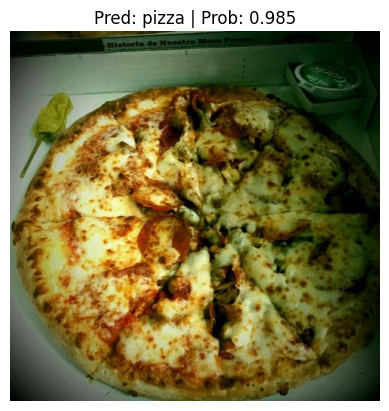

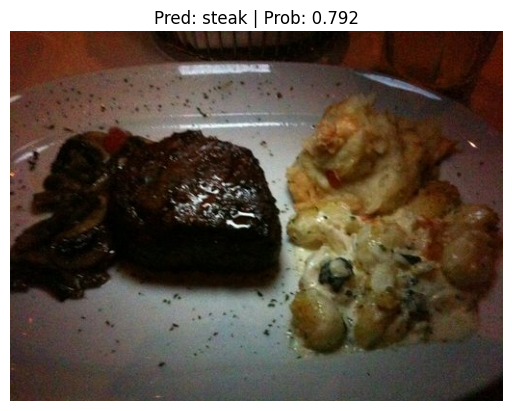

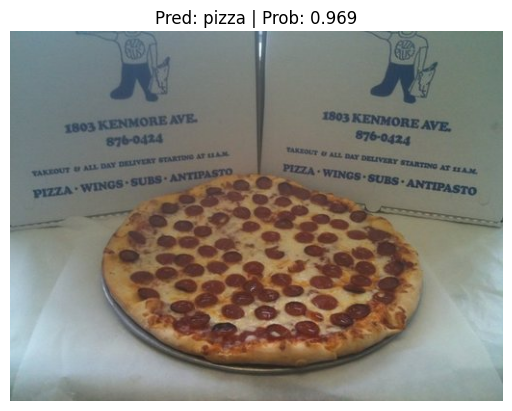

In [134]:
# Get a random list of image paths from test set
import random
random.seed(1000)
num_images_to_plot = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg")) # get list all image paths from test data 
test_image_path_sample = random.sample(population=test_image_path_list, # go through all of the test image paths
                                       k=num_images_to_plot) # randomly select 'k' image paths to pred and plot

# Make predictions on and plot the images
for image_path in test_image_path_sample:
    pred_and_plot_image(model=loaded_model, 
                        image_path=image_path,
                        class_names=class_names,
                        image_size=(224, 224),
                        device=device)

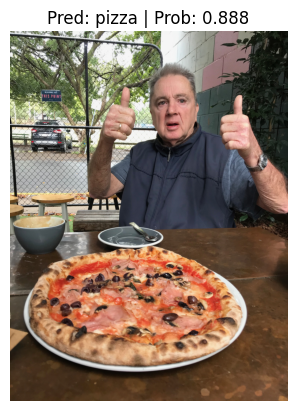

In [97]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = Path("data") / "04-pizza-dad.jpeg"

# Predict on custom image
pred_and_plot_image(model=loaded_model,
                    image_path=custom_image_path,
                    class_names=class_names)

## Retraining v0 Model (EfficientNet-B0)

This section retrains the v0 model to restore it after accidental overwrite. Using the same seed for fair comparison with v1.

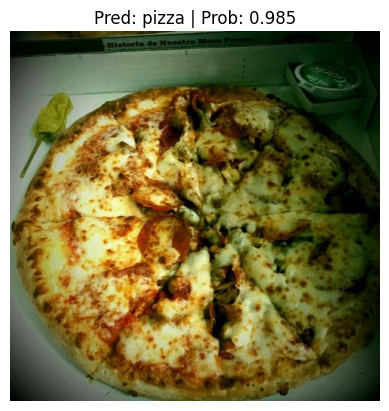

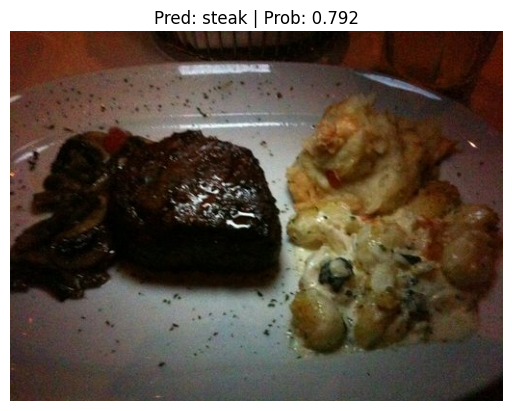

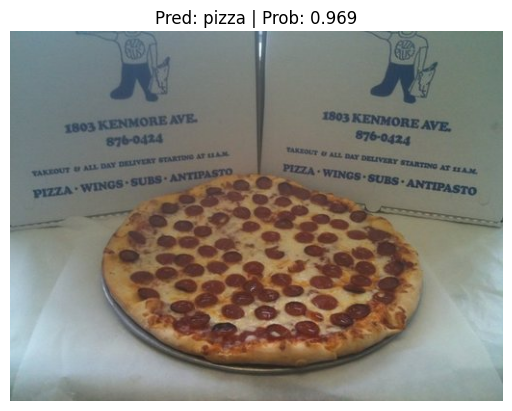

In [137]:
# Get a random list of image paths from test set
import random
random.seed(1000)
num_images_to_plot = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg")) # get list all image paths from test data 
test_image_path_sample = random.sample(population=test_image_path_list, # go through all of the test image paths
                                       k=num_images_to_plot) # randomly select 'k' image paths to pred and plot

# Make predictions on and plot the images
for image_path in test_image_path_sample:
    pred_and_plot_image(model=loaded_model, 
                        image_path=image_path,
                        class_names=class_names,
                        image_size=(224, 224),
                        device=device)

In [138]:
# Load v0 model for inference
loaded_model_v0 = torchvision.models.efficientnet_b0(weights=None)

# Freeze all base layers
for param in loaded_model_v0.features.parameters():
    param.requires_grad = False

# Replace classifier to match v0 architecture
loaded_model_v0.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280, out_features=output_shape, bias=True)
)

# Load the saved state dict
MODEL_SAVE_PATH_V0 = Path("Models/transfer_trained_model_v0")
loaded_model_v0.load_state_dict(torch.load(f=MODEL_SAVE_PATH_V0, map_location=device))

# Move to device and set to eval mode
loaded_model_v0 = loaded_model_v0.to(device)
loaded_model_v0.eval()

print(f"v0 model loaded successfully from {MODEL_SAVE_PATH_V0}")

v0 model loaded successfully from Models/transfer_trained_model_v0


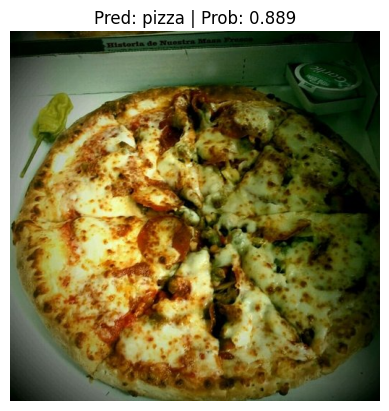

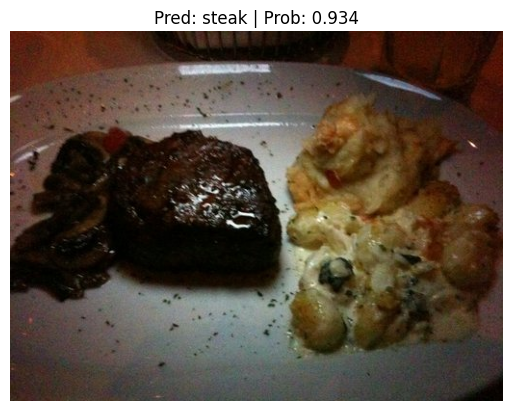

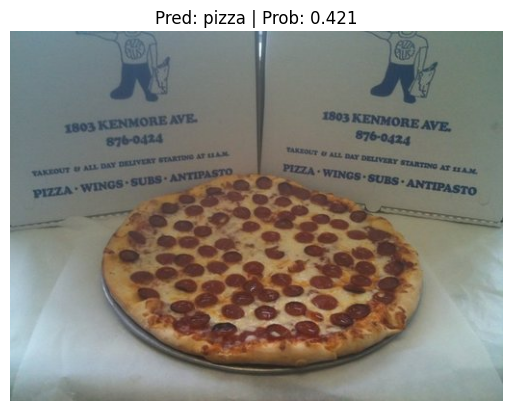

In [139]:
# Get a random list of image paths from test set
import random
random.seed(1000)
num_images_to_plot = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg")) # get list all image paths from test data 
test_image_path_sample = random.sample(population=test_image_path_list, # go through all of the test image paths
                                       k=num_images_to_plot) # randomly select 'k' image paths to pred and plot

# Make predictions on and plot the images
for image_path in test_image_path_sample:
    pred_and_plot_image(model=loaded_model_v0, 
                        image_path=image_path,
                        class_names=class_names,
                        image_size=(224, 224),
                        device=device)